# **Bibliotecas usadas**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report

# **Usando o Balanced**

In [5]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

average = (0.2860,)
standard_deviation = (0.3530,)


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(average, standard_deviation)
])

Usando device: cpu


In [6]:
train_all = torchvision.datasets.EMNIST(
    root = './balanced',
    split = 'balanced',
    train = True,
    download = True,
    transform = transform
)

test_ds = torchvision.datasets.EMNIST(
    root = './balanced',
    split = 'balanced',
    train = False,
    download = True,
    transform = transform
)

n_val = round(len(train_all) * 0.2)
n_treino = len(train_all) - n_val
treino_ds, val_ds = random_split(
    train_all, [n_treino, n_val],
    generator=torch.Generator().manual_seed(seed)
)

In [7]:
train_loader = DataLoader(treino_ds, batch_size = 128, shuffle = True, num_workers = 2, pin_memory = True)
val_loader = DataLoader(val_ds, batch_size = 128, shuffle = False, num_workers = 2, pin_memory = True)
test_loader = DataLoader(test_ds, batch_size = 128, shuffle = False, num_workers = 2, pin_memory = True)

Xb, yb = next(iter(train_loader))

c:\Users\PP\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


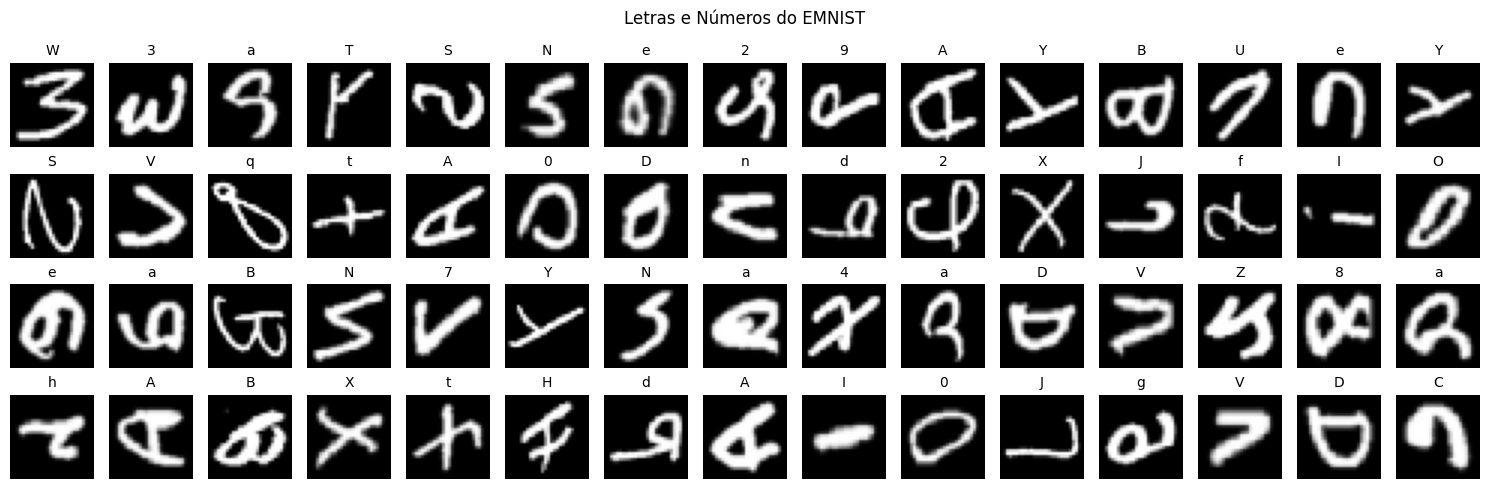

In [8]:
desnormalizar = lambda iter: iter * standard_deviation[0] + average[0]

fig, axes = plt.subplots(4, 15, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(
        desnormalizar(Xb[i]).squeeze().numpy(),
        cmap='gray'
    )
    ax.set_title(train_all.classes[yb[i].item()], fontsize=10)
    ax.axis("off")
plt.suptitle("Letras e Números do EMNIST")
plt.tight_layout()
plt.show()

In [9]:
class MLP_EMNIST(nn.Module):
    def __init__(self, n_classes: int = len(train_all.classes)):
        super().__init__()
        self.linear_relu_stack = nn.Sequential( # Sequência de camadas lineares e ReLU
            nn.Flatten(), # Transforma a imagem 28x28 em um vetor de 784 elementos
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3), # Adiciona dropout para evitar overfitting
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Adiciona dropout para evitar overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        '''Função de propagação para frente do modelo'''
        return self.linear_relu_stack(x)
    
model = MLP_EMNIST().to(device)

print(model, end = '\n\n')
print(f"Número de parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MLP_EMNIST(
  (linear_relu_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=47, bias=True)
  )
)

Número de parâmetros treináveis: 572,207


In [10]:
N_EPOCAS = 200
criterio  = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
#scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCAS)

writer = SummaryWriter(log_dir="runs/Letters_and_Numbers_Emnist_mlp")
# Registrar o grafo do modelo no TensorBoard
writer.add_graph(model, Xb.to(device))

In [11]:
def treinar_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = modelo(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
        
    return loss_total/total, acertos/total


def avaliar(modelo, loader, criterio, device):
    modelo.eval()
    loss_total, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = modelo(Xb)
            loss = criterio(logits, yb)
            loss_total += loss.item() * Xb.size(0)
            acertos    += (logits.argmax(1) == yb).sum().item()
            total      += yb.size(0)
            
    return loss_total/total, acertos/total

In [ ]:

historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
melhor_val = 0.0

for epoca in tqdm(range(1, N_EPOCAS + 1)):
    tr_loss, tr_acc = treinar_epoca(model, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(model, val_loader, criterio, device)
    scheduler.step()

    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)

    # TensorBoard
    writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)
    writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoca)
    for nome, param in model.named_parameters():
        writer.add_histogram(nome, param, epoca)

    # Salva o melhor modelo
    if vl_acc > melhor_val:
        melhor_val = vl_acc
        torch.save({
            "epoca": epoca,
            "modelo_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": vl_acc,
        }, "balanced.pth")

    print(f"Época {epoca:02d} | treino loss={tr_loss:.4f} acc={tr_acc:.4f} "
          f"| val loss={vl_loss:.4f} acc={vl_acc:.4f}")

writer.close()
print(f"\nMelhor acurácia de validação: {melhor_val:.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]

Época 01 | treino loss=1.1976 acc=0.6415 | val loss=0.6799 acc=0.7846
Época 02 | treino loss=0.7231 acc=0.7649 | val loss=0.5661 acc=0.8135
Época 03 | treino loss=0.6305 acc=0.7883 | val loss=0.5374 acc=0.8217
Época 04 | treino loss=0.5801 acc=0.8035 | val loss=0.4953 acc=0.8259
Época 05 | treino loss=0.5463 acc=0.8133 | val loss=0.4809 acc=0.8386
Época 06 | treino loss=0.5187 acc=0.8200 | val loss=0.4765 acc=0.8392
Época 07 | treino loss=0.5028 acc=0.8253 | val loss=0.4544 acc=0.8466
Época 08 | treino loss=0.4853 acc=0.8295 | val loss=0.4565 acc=0.8430
Época 09 | treino loss=0.4713 acc=0.8339 | val loss=0.4598 acc=0.8424
Época 10 | treino loss=0.4590 acc=0.8371 | val loss=0.4421 acc=0.8492
Época 11 | treino loss=0.4486 acc=0.8396 | val loss=0.4475 acc=0.8474
Época 12 | treino loss=0.4410 acc=0.8402 | val loss=0.4444 acc=0.8515
Época 13 | treino loss=0.4304 acc=0.8446 | val loss=0.4426 acc=0.8510
Época 14 | treino loss=0.4270 acc=0.8462 | val loss=0.4367 acc=0.8519
Época 15 | treino lo

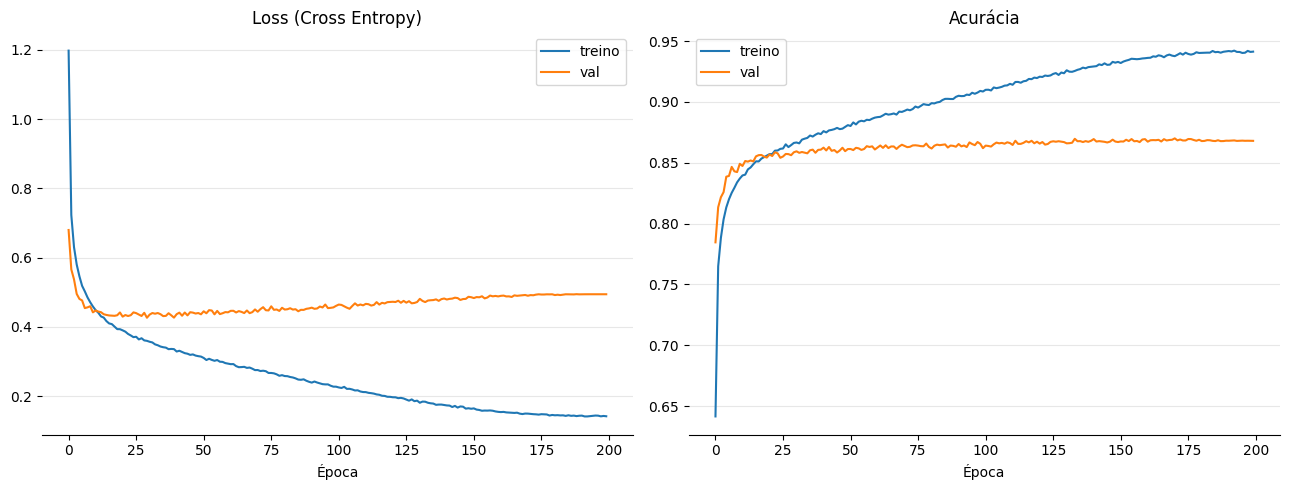

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(historico["train_loss"], label="treino")
axes[0].plot(historico["val_loss"], label="val")
axes[0].set_title("Loss (Cross Entropy)")
axes[0].set_xlabel("Época")
axes[0].legend(); axes[0].grid(alpha=0.3, axis = 'y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)

axes[1].plot(historico["train_acc"], label="treino")
axes[1].plot(historico["val_acc"], label="val")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend(); axes[1].grid(alpha=0.3, axis = 'y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
modelo_final = MLP_EMNIST().to(device)
ckpt = torch.load("melhor_mlp_letters_and_numbers.pth", map_location=device)
modelo_final.load_state_dict(ckpt["modelo_state"])
modelo_final.eval()
print(f"Carregado checkpoint da época {ckpt['epoca']} (val_acc={ckpt['val_acc']:.4f})")

Carregado checkpoint da época 171 (val_acc=0.8701)


In [15]:
all_y, all_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = modelo_final(Xb)
        preds = logits.argmax(1).cpu().numpy()
        all_y.extend(yb.numpy()); all_pred.extend(preds)

all_y, all_pred = np.array(all_y), np.array(all_pred)
acc = (all_y == all_pred).mean()
print(f"Acurácia no teste: {acc:.4f}\n")
print(classification_report(all_y, all_pred, target_names=train_all.classes))

Acurácia no teste: 0.8657

              precision    recall  f1-score   support

           0       0.65      0.69      0.67       400
           1       0.55      0.72      0.63       400
           2       0.93      0.86      0.89       400
           3       0.96      0.97      0.96       400
           4       0.91      0.91      0.91       400
           5       0.90      0.86      0.88       400
           6       0.93      0.92      0.92       400
           7       0.96      0.96      0.96       400
           8       0.92      0.92      0.92       400
           9       0.68      0.78      0.72       400
           A       0.96      0.95      0.96       400
           B       0.93      0.94      0.93       400
           C       0.95      0.95      0.95       400
           D       0.91      0.89      0.90       400
           E       0.96      0.96      0.96       400
           F       0.67      0.58      0.62       400
           G       0.93      0.94      0.93       400


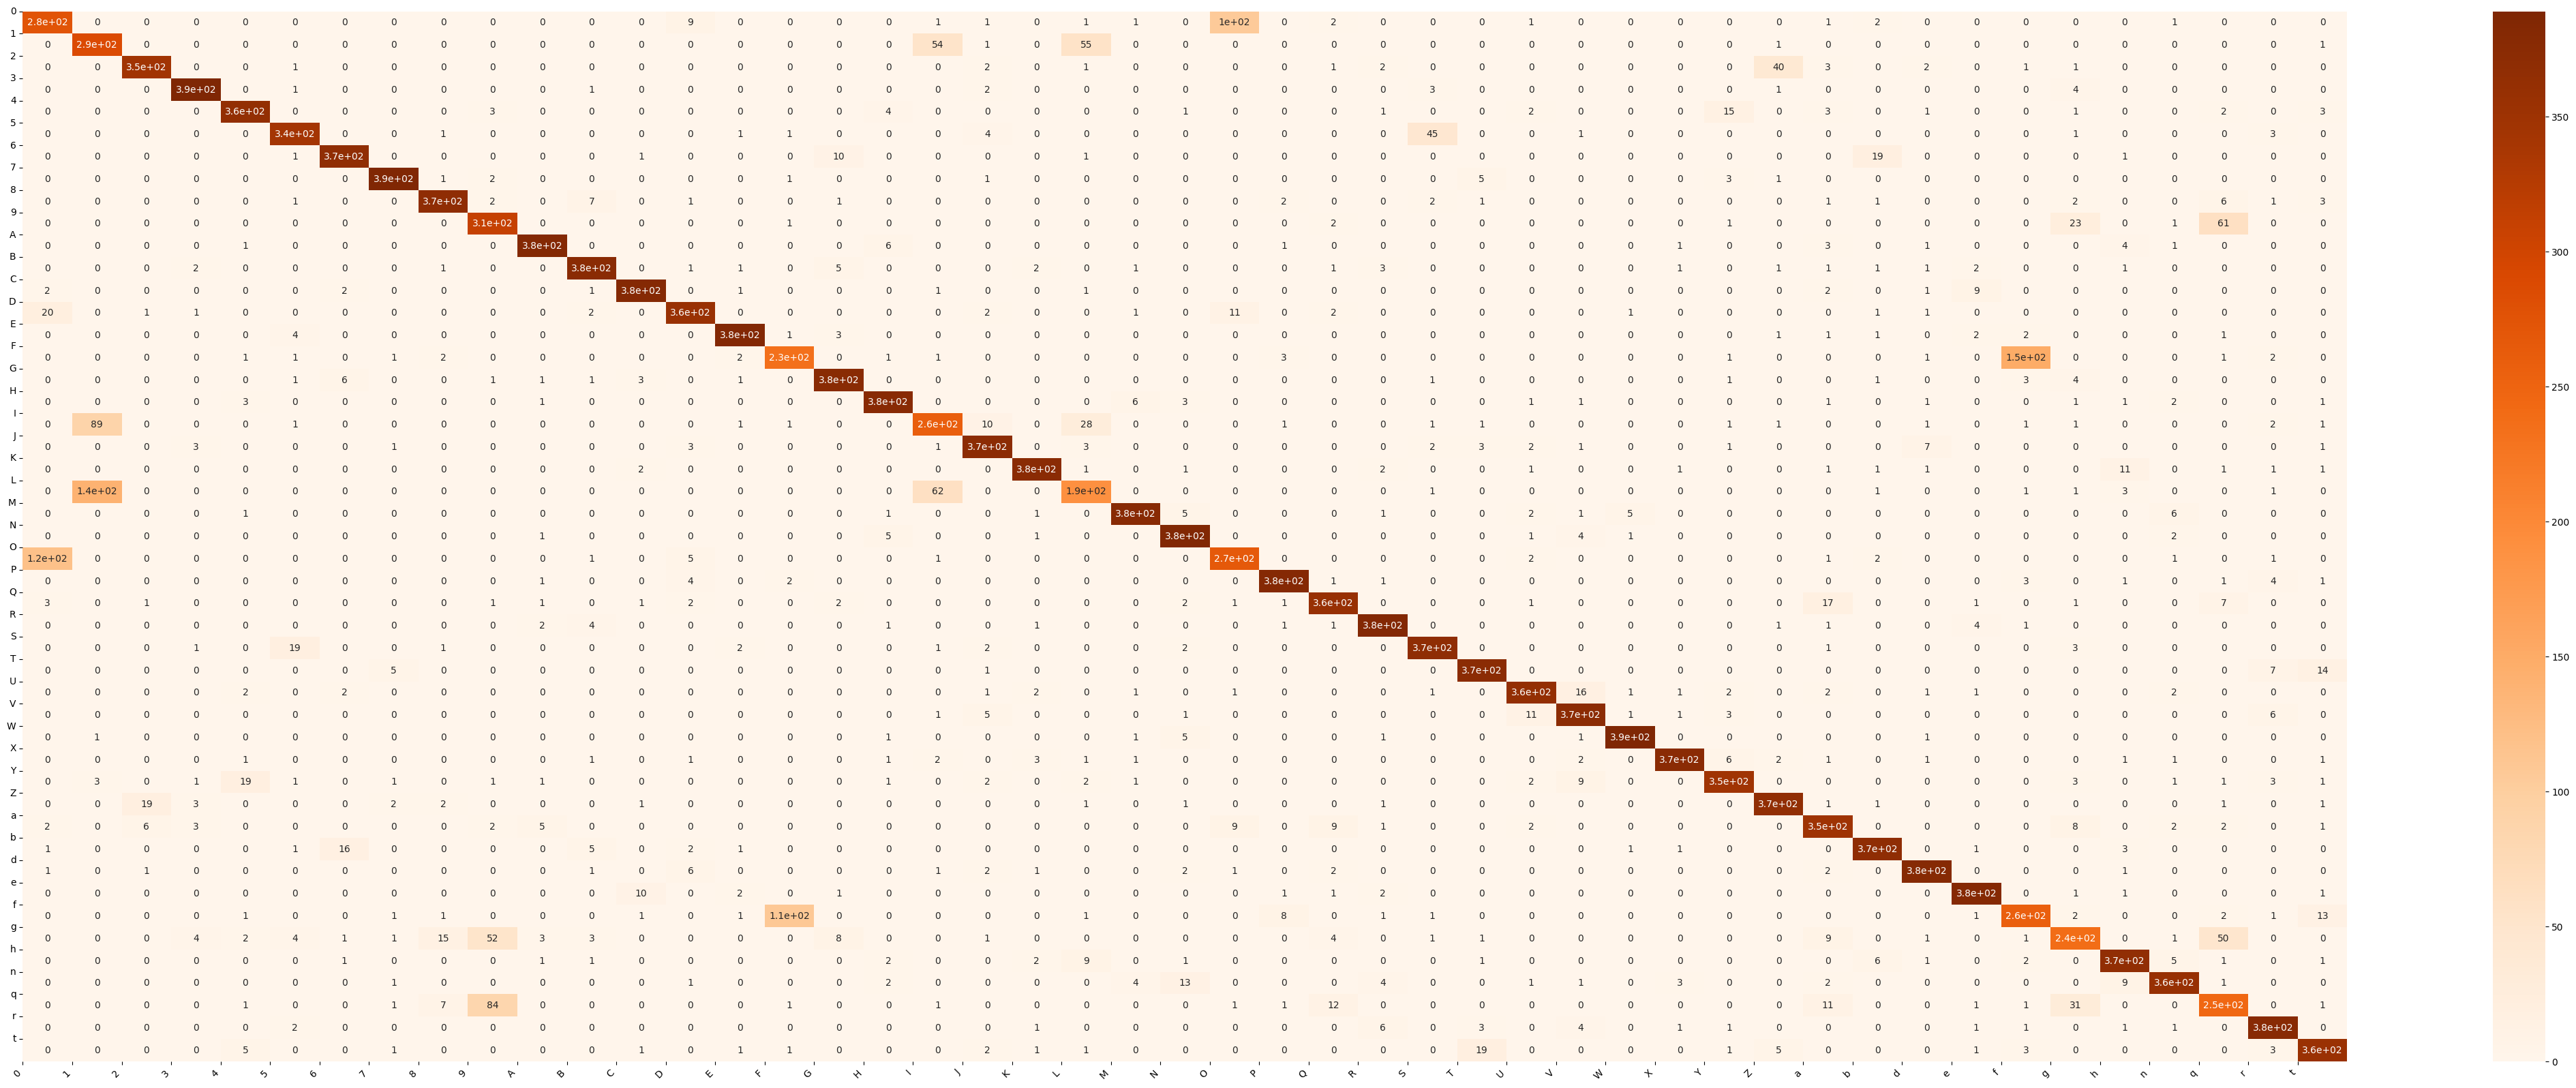

In [16]:
cm = confusion_matrix(all_y, all_pred)

plt.figure(figsize=(55, 20))
sns.heatmap(cm, cmap="Oranges", annot=True)
plt.xticks(range(len(train_all.classes)), train_all.classes, rotation=45, ha='right')
plt.yticks(range(len(train_all.classes)), train_all.classes, rotation=0, ha='right')
plt.show()

c:\Users\PP\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


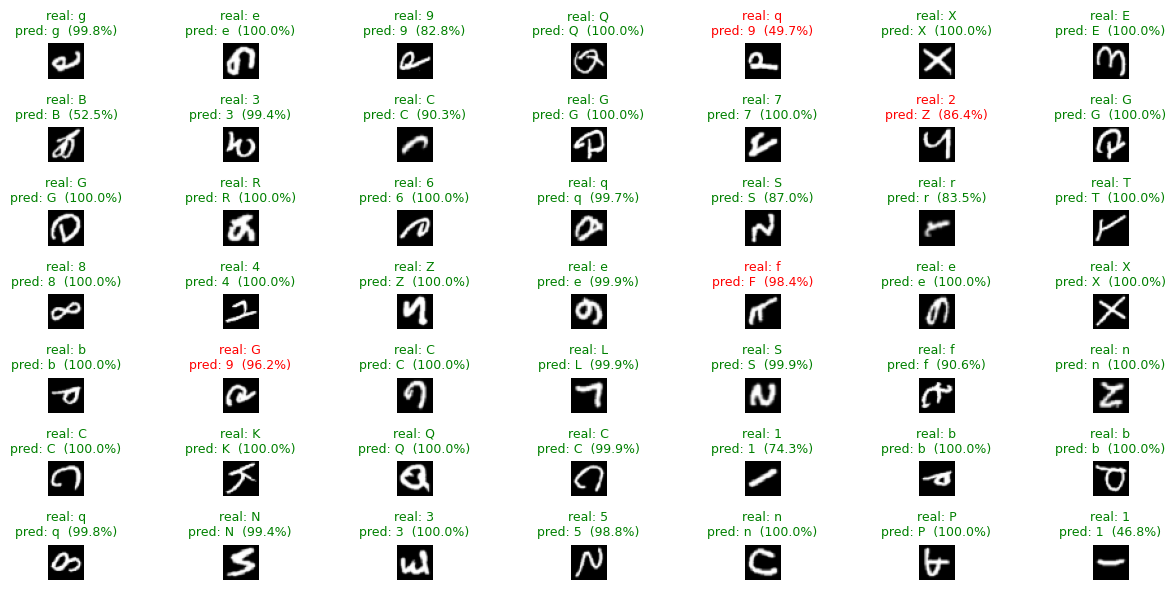

In [17]:
Xb, yb = next(iter(test_loader))
with torch.no_grad():
    logits = modelo_final(Xb.to(device))
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(1)

fig, axes = plt.subplots(7, 7, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).squeeze().numpy()
    ax.imshow(img, cmap='gray')
    cor = "green" if preds[i] == yb[i] else "red"
    ax.set_title(
        f"real: {train_all.classes[yb[i]]}\npred: {train_all.classes[preds[i]]}  ({probs[i, preds[i]]*100:.1f}%)",
        color=cor, fontsize=9
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

# **Usando o ByMerge**

In [3]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

average = (0.2860,)
standard_deviation = (0.3530,)


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(average, standard_deviation)
])

Usando device: cpu


In [4]:
train_all = torchvision.datasets.EMNIST(
    root = './bymerge',
    split = 'bymerge',
    train = True,
    download = True,
    transform = transform
)

test_ds = torchvision.datasets.EMNIST(
    root = './bymerge',
    split = 'bymerge',
    train = False,
    download = True,
    transform = transform
)

n_val = round(len(train_all) * 0.2)
n_treino = len(train_all) - n_val
treino_ds, val_ds = random_split(
    train_all, [n_treino, n_val],
    generator=torch.Generator().manual_seed(seed)
)

In [5]:
train_loader = DataLoader(treino_ds, batch_size = 128, shuffle = True, num_workers = 2, pin_memory = True)
val_loader = DataLoader(val_ds, batch_size = 128, shuffle = False, num_workers = 2, pin_memory = True)
test_loader = DataLoader(test_ds, batch_size = 128, shuffle = False, num_workers = 2, pin_memory = True)

Xb, yb = next(iter(train_loader))

c:\Users\PP\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


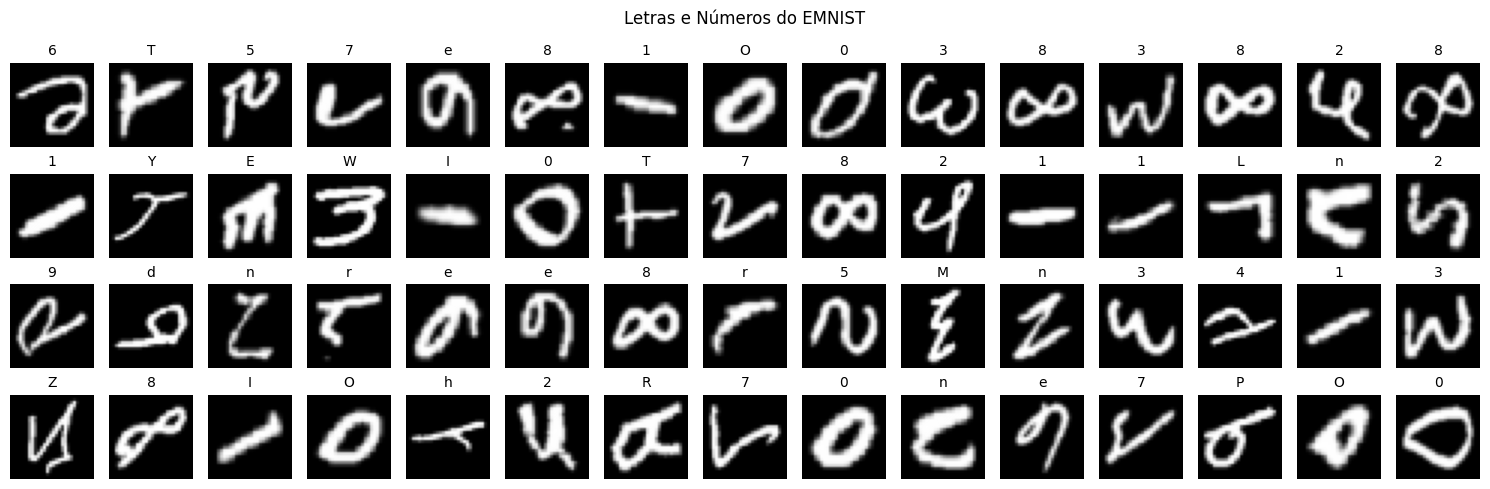

In [6]:
desnormalizar = lambda iter: iter * standard_deviation[0] + average[0]

fig, axes = plt.subplots(4, 15, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(
        desnormalizar(Xb[i]).squeeze().numpy(),
        cmap='gray'
    )
    ax.set_title(train_all.classes[yb[i].item()], fontsize=10)
    ax.axis("off")
plt.suptitle("Letras e Números do EMNIST")
plt.tight_layout()
plt.show()

In [7]:
class MLP_EMNIST(nn.Module):
    def __init__(self, n_classes: int = len(train_all.classes)):
        super().__init__()
        self.linear_relu_stack = nn.Sequential( # Sequência de camadas lineares e ReLU
            nn.Flatten(), # Transforma a imagem 28x28 em um vetor de 784 elementos
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3), # Adiciona dropout para evitar overfitting
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Adiciona dropout para evitar overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        '''Função de propagação para frente do modelo'''
        return self.linear_relu_stack(x)
    
model = MLP_EMNIST().to(device)

print(model, end = '\n\n')
print(f"Número de parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MLP_EMNIST(
  (linear_relu_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=47, bias=True)
  )
)

Número de parâmetros treináveis: 572,207


In [8]:
N_EPOCAS = 200
criterio  = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
#scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCAS)

writer = SummaryWriter(log_dir="runs/Letters_and_Numbers_Emnist_mlp")
# Registrar o grafo do modelo no TensorBoard
writer.add_graph(model, Xb.to(device))

In [9]:
def treinar_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = modelo(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
        
    return loss_total/total, acertos/total


def avaliar(modelo, loader, criterio, device):
    modelo.eval()
    loss_total, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = modelo(Xb)
            loss = criterio(logits, yb)
            loss_total += loss.item() * Xb.size(0)
            acertos    += (logits.argmax(1) == yb).sum().item()
            total      += yb.size(0)
            
    return loss_total/total, acertos/total

In [10]:

historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
melhor_val = 0.0

for epoca in tqdm(range(1, N_EPOCAS + 1)):
    tr_loss, tr_acc = treinar_epoca(model, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(model, val_loader, criterio, device)
    scheduler.step()

    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)

    # TensorBoard
    writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)
    writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoca)
    for nome, param in model.named_parameters():
        writer.add_histogram(nome, param, epoca)

    # Salva o melhor modelo
    if vl_acc > melhor_val:
        melhor_val = vl_acc
        torch.save({
            "epoca": epoca,
            "modelo_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": vl_acc,
        }, "bymerge.pth")

    print(f"Época {epoca:02d} | treino loss={tr_loss:.4f} acc={tr_acc:.4f} "
          f"| val loss={vl_loss:.4f} acc={vl_acc:.4f}")

writer.close()
print(f"\nMelhor acurácia de validação: {melhor_val:.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]

Época 01 | treino loss=0.6460 acc=0.7931 | val loss=0.4169 acc=0.8567
Época 02 | treino loss=0.4795 acc=0.8387 | val loss=0.3862 acc=0.8671
Época 03 | treino loss=0.4507 acc=0.8468 | val loss=0.3691 acc=0.8697
Época 04 | treino loss=0.4361 acc=0.8514 | val loss=0.3601 acc=0.8728
Época 05 | treino loss=0.4241 acc=0.8549 | val loss=0.3516 acc=0.8766
Época 06 | treino loss=0.4169 acc=0.8571 | val loss=0.3502 acc=0.8761
Época 07 | treino loss=0.4094 acc=0.8599 | val loss=0.3537 acc=0.8755
Época 08 | treino loss=0.4043 acc=0.8609 | val loss=0.3433 acc=0.8786
Época 09 | treino loss=0.4003 acc=0.8621 | val loss=0.3425 acc=0.8799
Época 10 | treino loss=0.3964 acc=0.8630 | val loss=0.3402 acc=0.8802
Época 11 | treino loss=0.3925 acc=0.8644 | val loss=0.3430 acc=0.8805
Época 12 | treino loss=0.3905 acc=0.8649 | val loss=0.3367 acc=0.8824
Época 13 | treino loss=0.3871 acc=0.8659 | val loss=0.3401 acc=0.8806
Época 14 | treino loss=0.3857 acc=0.8666 | val loss=0.3347 acc=0.8824
Época 15 | treino lo

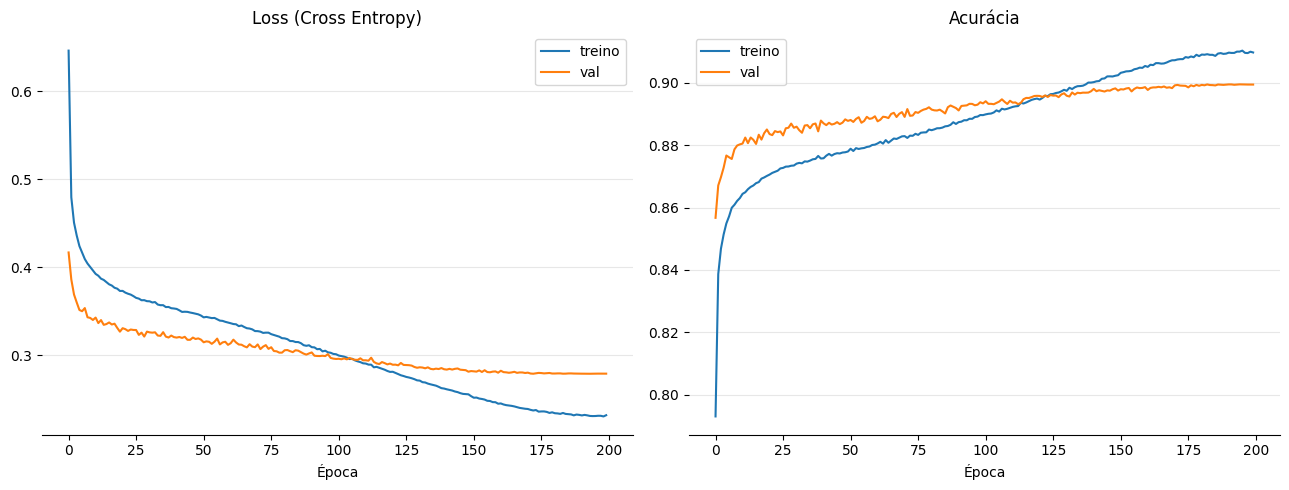

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(historico["train_loss"], label="treino")
axes[0].plot(historico["val_loss"], label="val")
axes[0].set_title("Loss (Cross Entropy)")
axes[0].set_xlabel("Época")
axes[0].legend(); axes[0].grid(alpha=0.3, axis = 'y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)

axes[1].plot(historico["train_acc"], label="treino")
axes[1].plot(historico["val_acc"], label="val")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend(); axes[1].grid(alpha=0.3, axis = 'y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
modelo_final = MLP_EMNIST().to(device)
ckpt = torch.load("bymerge.pth", map_location=device)
modelo_final.load_state_dict(ckpt["modelo_state"])
modelo_final.eval()
print(f"Carregado checkpoint da época {ckpt['epoca']} (val_acc={ckpt['val_acc']:.4f})")

Carregado checkpoint da época 195 (val_acc=0.8994)


In [15]:
all_y, all_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = modelo_final(Xb)
        preds = logits.argmax(1).cpu().numpy()
        all_y.extend(yb.numpy()); all_pred.extend(preds)

all_y, all_pred = np.array(all_y), np.array(all_pred)
acc = (all_y == all_pred).mean()
print(f"Acurácia no teste: {acc:.4f}\n")
print(classification_report(all_y, all_pred, target_names=train_all.classes))

Acurácia no teste: 0.9000

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      5745
           1       0.69      0.90      0.78      6400
           2       0.96      0.97      0.96      5765
           3       0.99      0.99      0.99      5827
           4       0.97      0.98      0.97      5498
           5       0.95      0.92      0.94      5326
           6       0.97      0.98      0.97      5787
           7       0.98      0.99      0.99      5873
           8       0.98      0.98      0.98      5655
           9       0.92      0.98      0.95      5651
           A       0.93      0.98      0.95      1058
           B       0.93      0.92      0.93       652
           C       0.96      0.96      0.96      2156
           D       0.88      0.88      0.88       735
           E       0.95      0.96      0.95       860
           F       0.80      0.93      0.86      1524
           G       0.91      0.87      0.89       430


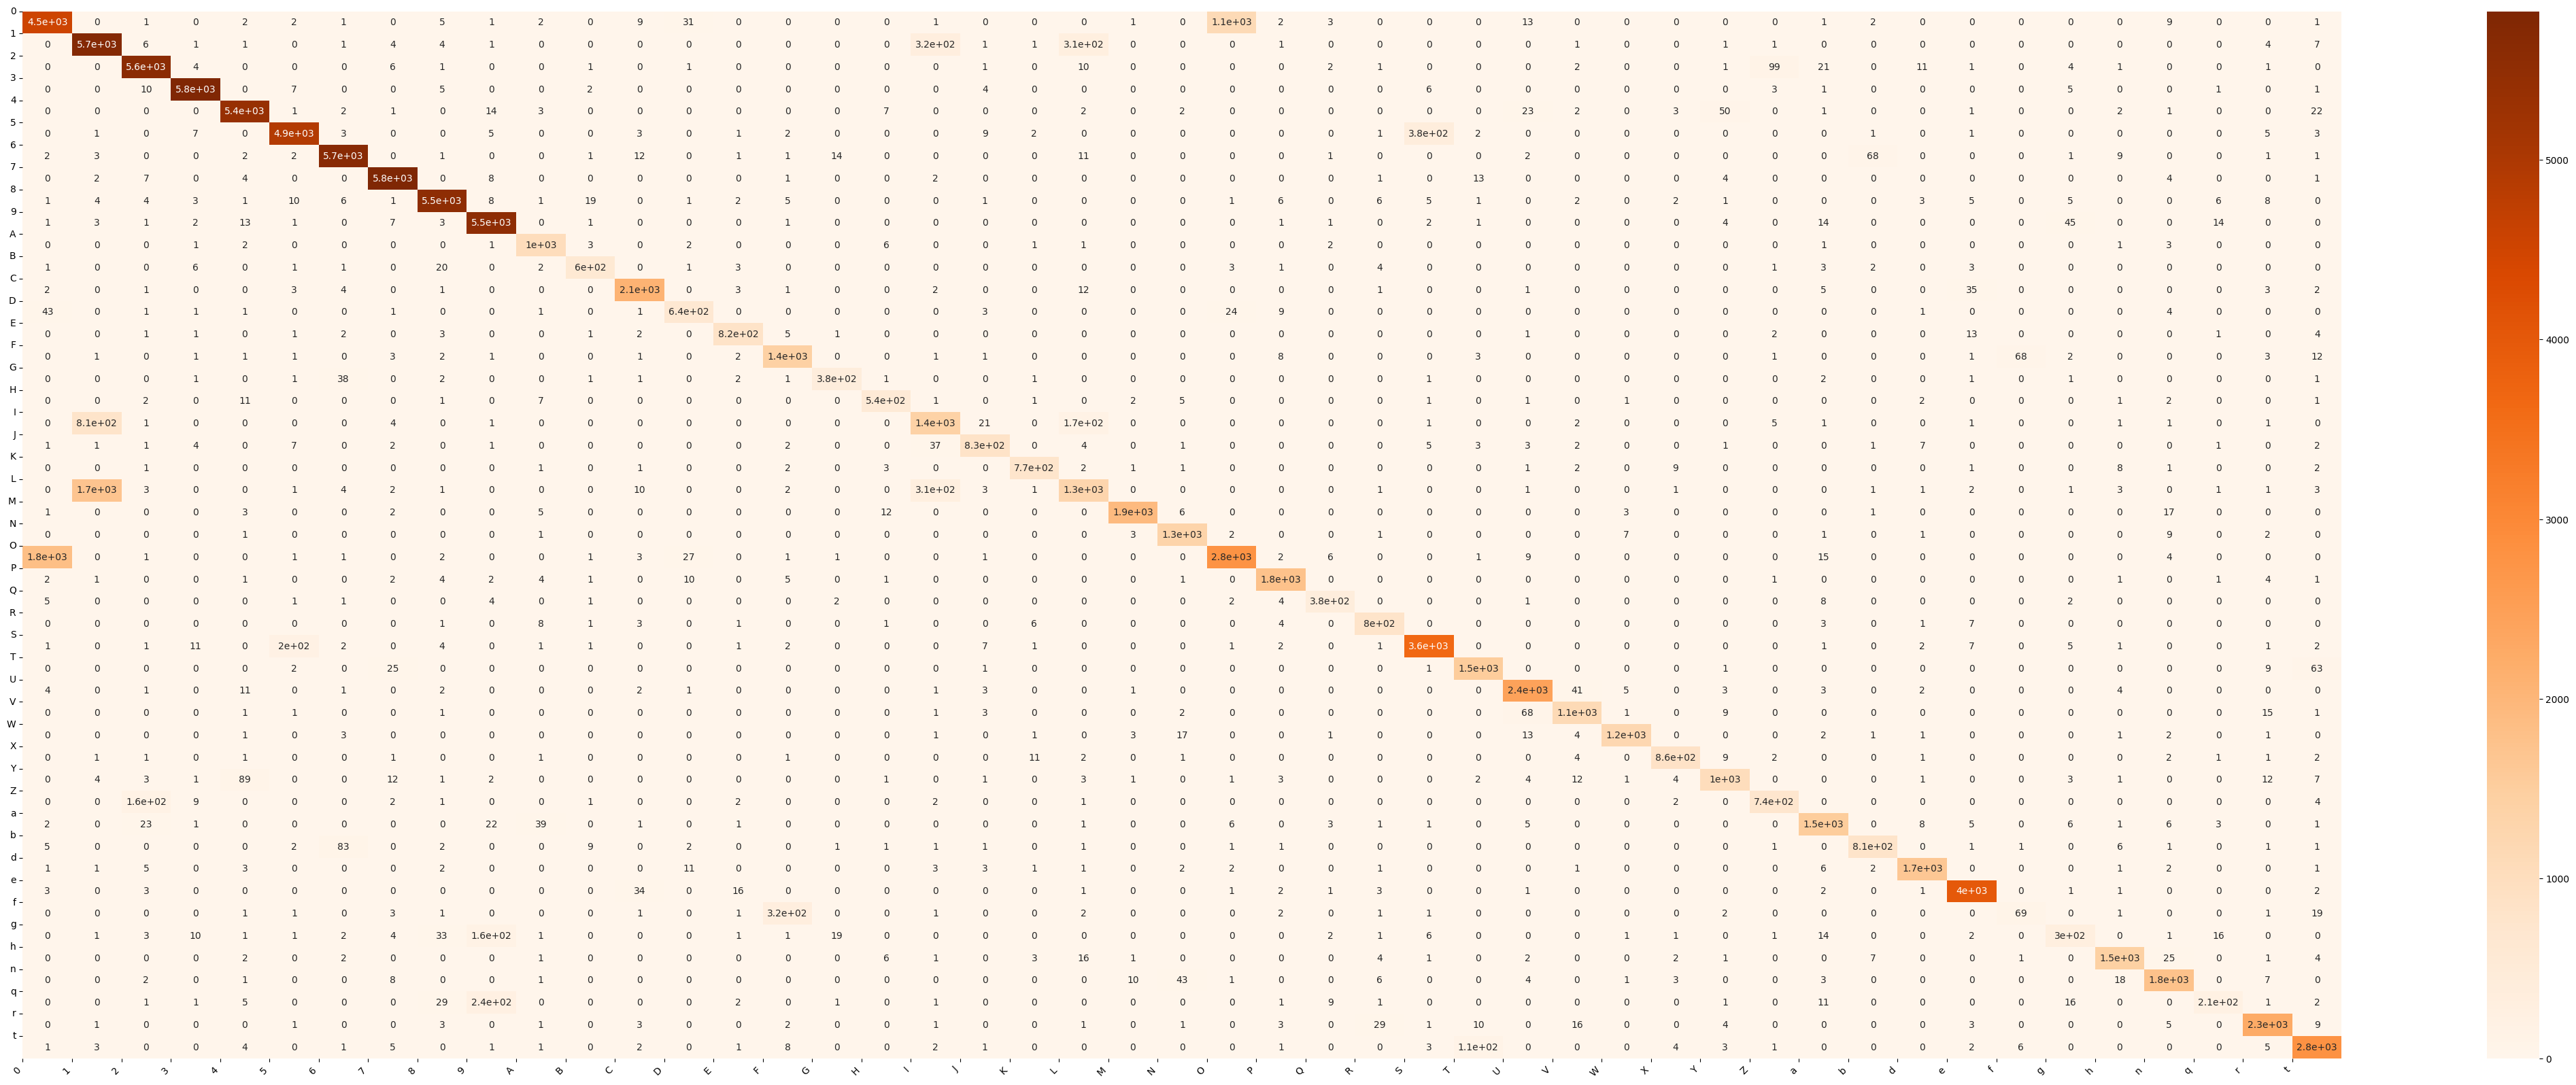

In [16]:
cm = confusion_matrix(all_y, all_pred)

plt.figure(figsize=(55, 20))
sns.heatmap(cm, cmap="Oranges", annot=True)
plt.xticks(range(len(train_all.classes)), train_all.classes, rotation=45, ha='right')
plt.yticks(range(len(train_all.classes)), train_all.classes, rotation=0, ha='right')
plt.show()

c:\Users\PP\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


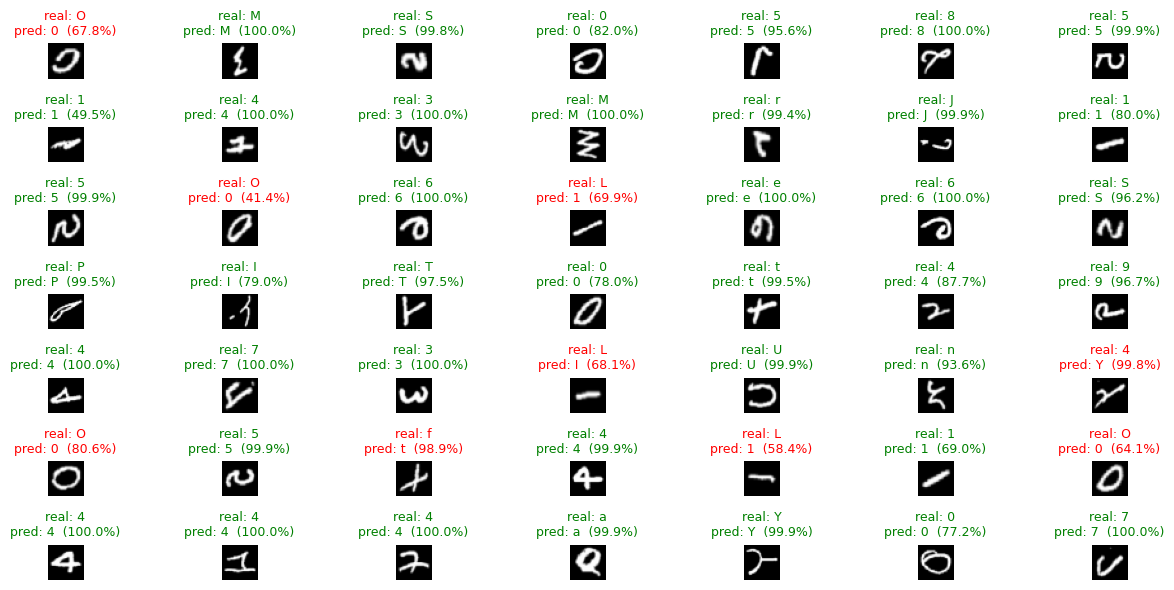

In [17]:
Xb, yb = next(iter(test_loader))
with torch.no_grad():
    logits = modelo_final(Xb.to(device))
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(1)

fig, axes = plt.subplots(7, 7, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).squeeze().numpy()
    ax.imshow(img, cmap='gray')
    cor = "green" if preds[i] == yb[i] else "red"
    ax.set_title(
        f"real: {train_all.classes[yb[i]]}\npred: {train_all.classes[preds[i]]}  ({probs[i, preds[i]]*100:.1f}%)",
        color=cor, fontsize=9
    )
    ax.axis("off")
plt.tight_layout()
plt.show()